In [1]:
import pandas as pd

labels = pd.read_csv("data/list_attr_celeba.csv")

In [24]:
source_dir = "data/img/img_align_celeba"

In [2]:
print(labels.columns)

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')


In [18]:
men = labels[labels["Male"] == 1]

In [19]:
mustache_df = men[men["Mustache"] == 1]

clean_df = men[
    (men["Mustache"] == -1) &
    (men["No_Beard"] == 1)
]

Vill skapa ett balanserat dataset, och också ta bort kvinnor som aldrig har mustasch, så att modellen inte börjar tänka man eller kvinna istället för mustasch inte mustasch.

In [20]:
print("Män:", len(men))
print("Mustasch:", len(mustache_df))
print("Renrakad:", len(clean_df))

Män: 84434
Mustasch: 8414
Renrakad: 50899


balansera med 4000 bilder i varje klass

In [21]:
mustache_sample = mustache_df.sample(
    n=4000,
    random_state=42
)

clean_sample = clean_df.sample(
    n=4000,
    random_state=42
)

In [22]:
mustache_sample["label"] = "mustache"
clean_sample["label"] = "clean"

balanced_df = pd.concat([
    mustache_sample,
    clean_sample
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [23]:
print(len(mustache_df))
print(len(clean_df))

8414
50899


In [ ]:
import os
import shutil

os.makedirs("data/dataset/mustache", exist_ok=True)
os.makedirs("data/datasetclean", exist_ok=True)

for filename in mustache_sample["image_id"]:
    src = os.path.join(source_dir, filename)
    dst = os.path.join("data/dataset/mustache", filename)

    if os.path.exists(src):
        shutil.copy2(src, dst)

for filename in clean_sample["image_id"]:
    src = os.path.join(source_dir, filename)
    dst = os.path.join("data/dataset/clean", filename)

    if os.path.exists(src):
        shutil.copy2(src, dst)

In [26]:


print("Mustache:", len(os.listdir("data/dataset/mustache")))
print("Clean:", len(os.listdir("data/dataset/clean")))

Mustache: 4000
Clean: 4000


bilderna redo för tensorflow

In [27]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    "data/dataset",
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.


In [29]:
print(dataset.class_names)

['clean', 'mustache']


spana in några bilder

2026-06-01 20:46:46.659687: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


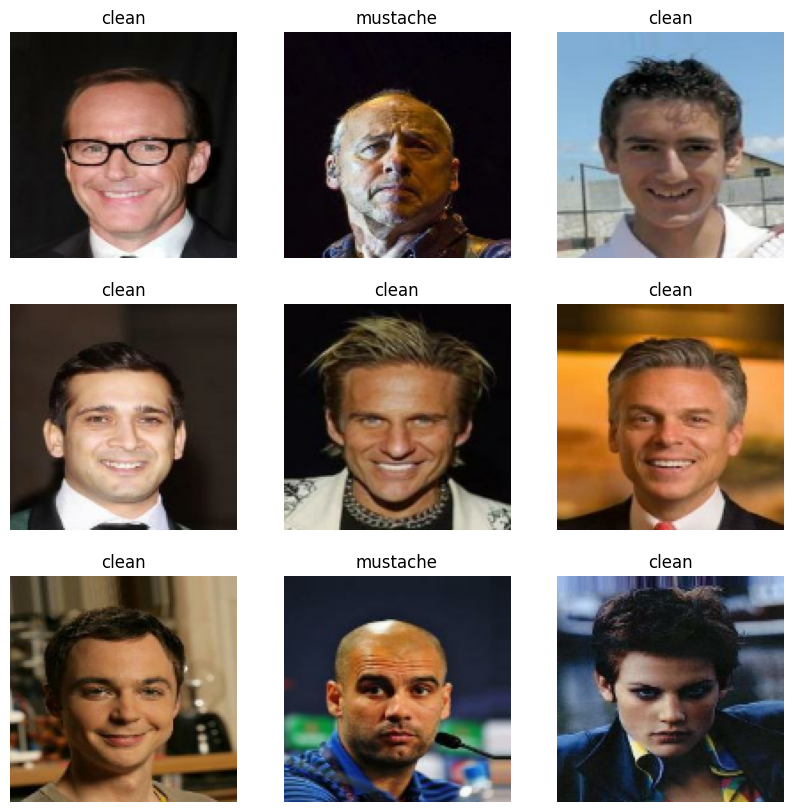

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(dataset.class_names[int(labels[i])])
        plt.axis("off")

plt.show()

Första testet

In [32]:

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Found 8000 files belonging to 2 classes.
Using 1600 files for validation.


In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reguarisering med early stop

In [37]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30


200/200 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - accuracy: 0.6700 - loss: 0.5869 - val_accuracy: 0.8375 - val_loss: 0.3754
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.8786 - loss: 0.2989 - val_accuracy: 0.8925 - val_loss: 0.2607
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.9175 - loss: 0.2151 - val_accuracy: 0.8619 - val_loss: 0.3122
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 173ms/step - accuracy: 0.9386 - loss: 0.1746 - val_accuracy: 0.8863 - val_loss: 0.3212
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 34s 172ms/step - accuracy: 0.9430 - loss: 0.1610 - val_accuracy: 0.9106 - val_loss: 0.2264
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 36s 178ms/step - accuracy: 0.9519 - loss: 0.1358 - val_accuracy: 0.9087 - val_loss: 0.2123
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.9567 - loss: 0.1199 - val_accuracy: 0.9150 - val_loss: 0.2180
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.9633 - loss: 0.1036 - val

In [38]:
model.evaluate(val_ds)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9087 - loss: 0.2123


[0.2123280167579651, 0.9087499976158142]

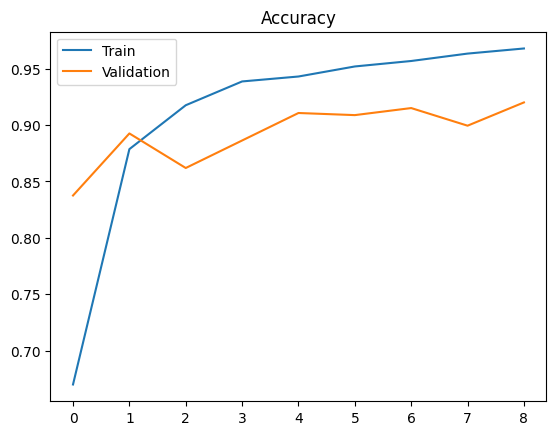

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

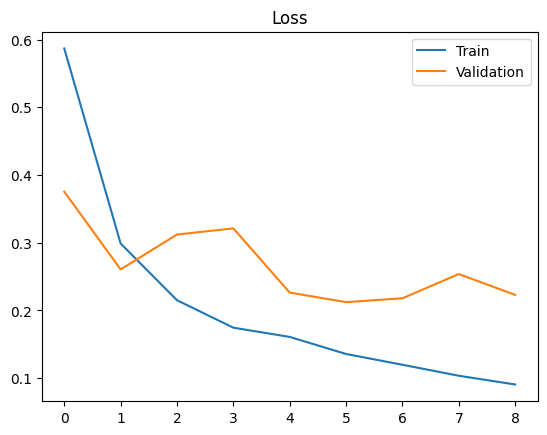

In [40]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')
plt.show()

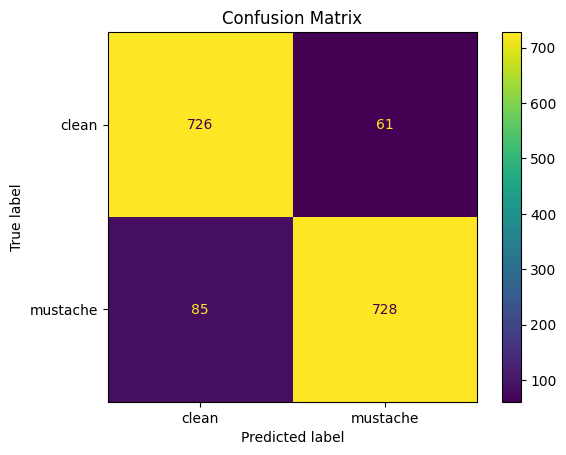

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([
    [726, 61],
    [85, 728]
])

class_names = ["clean", "mustache"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

dags att kolla på episka mustascher. har 4000 oanvända mustaschbilder att använda.

In [44]:
import os
import shutil

used_mustache_ids = set(mustache_sample["image_id"])

unused_mustache_df = mustache_df[
    ~mustache_df["image_id"].isin(used_mustache_ids)
].copy()

print("Oanvända mustaschbilder:", len(unused_mustache_df))

Oanvända mustaschbilder: 4414


In [45]:
source_dir = "data/img/img_align_celeba"
review_dir = "data/mustache_review_unused"

os.makedirs(review_dir, exist_ok=True)

for filename in unused_mustache_df["image_id"]:
    src = os.path.join(source_dir, filename)
    dst = os.path.join(review_dir, filename)

    if os.path.exists(src):
        shutil.copy2(src, dst)

print("Kopierade:", len(os.listdir(review_dir)))

Kopierade: 4414


In [46]:
os.makedirs("data/epic_dataset/epic", exist_ok=True)
os.makedirs("data/epic_dataset/thin", exist_ok=True)

spana in valideringsdatan

In [47]:


images_list = []
true_labels = []
pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0).flatten()
    
    images_list.append(images.numpy())
    true_labels.append(labels.numpy().flatten())
    pred_probs.append(preds)

images_arr = np.concatenate(images_list)
true_arr = np.concatenate(true_labels)
pred_arr = np.concatenate(pred_probs)

2026-06-02 07:44:24.197759: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [48]:
print(val_ds.class_names)

['clean', 'mustache']


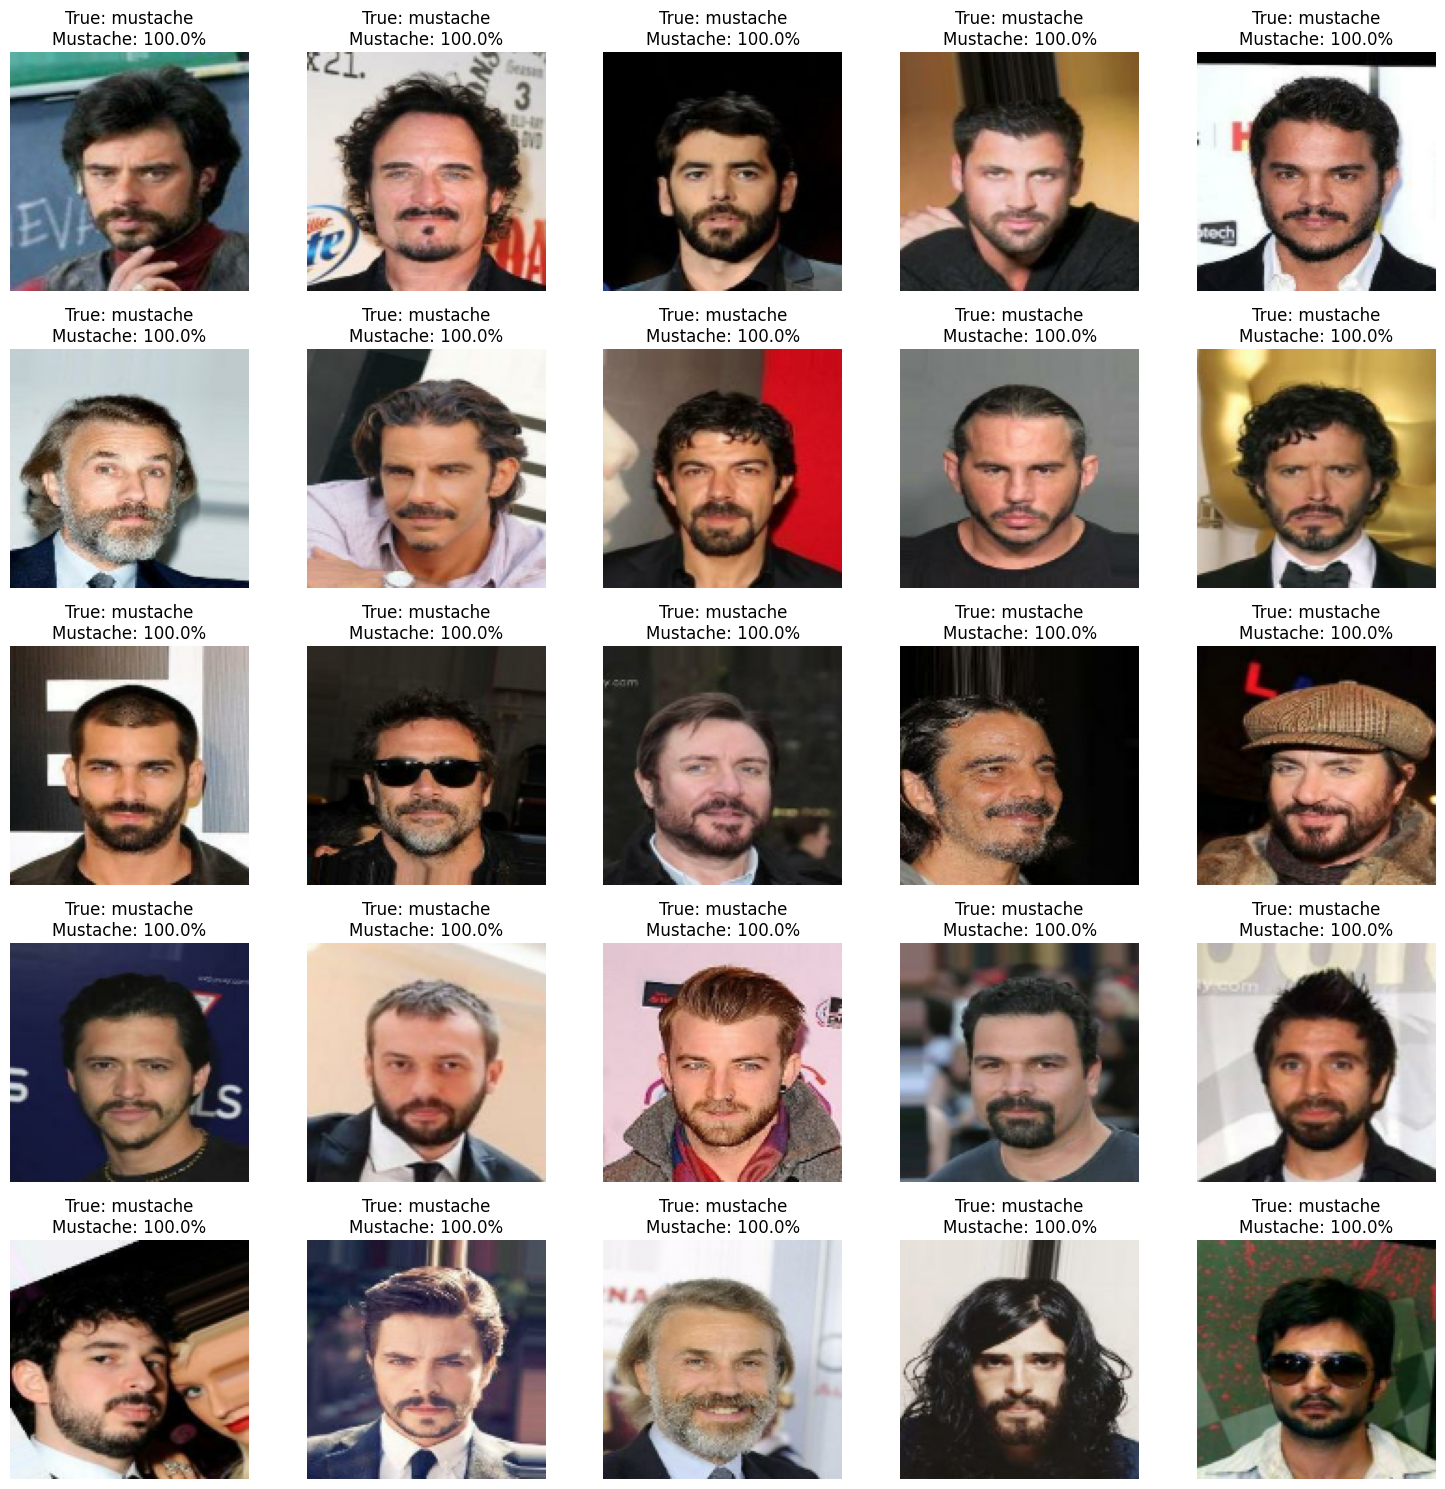

In [49]:
class_names = val_ds.class_names

top_idx = np.argsort(pred_arr)[-25:][::-1]

plt.figure(figsize=(15, 15))

for i, idx in enumerate(top_idx):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images_arr[idx].astype("uint8"))
    
    true_label = class_names[int(true_arr[idx])]
    pred_score = pred_arr[idx] * 100
    
    plt.title(f"True: {true_label}\nMustache: {pred_score:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

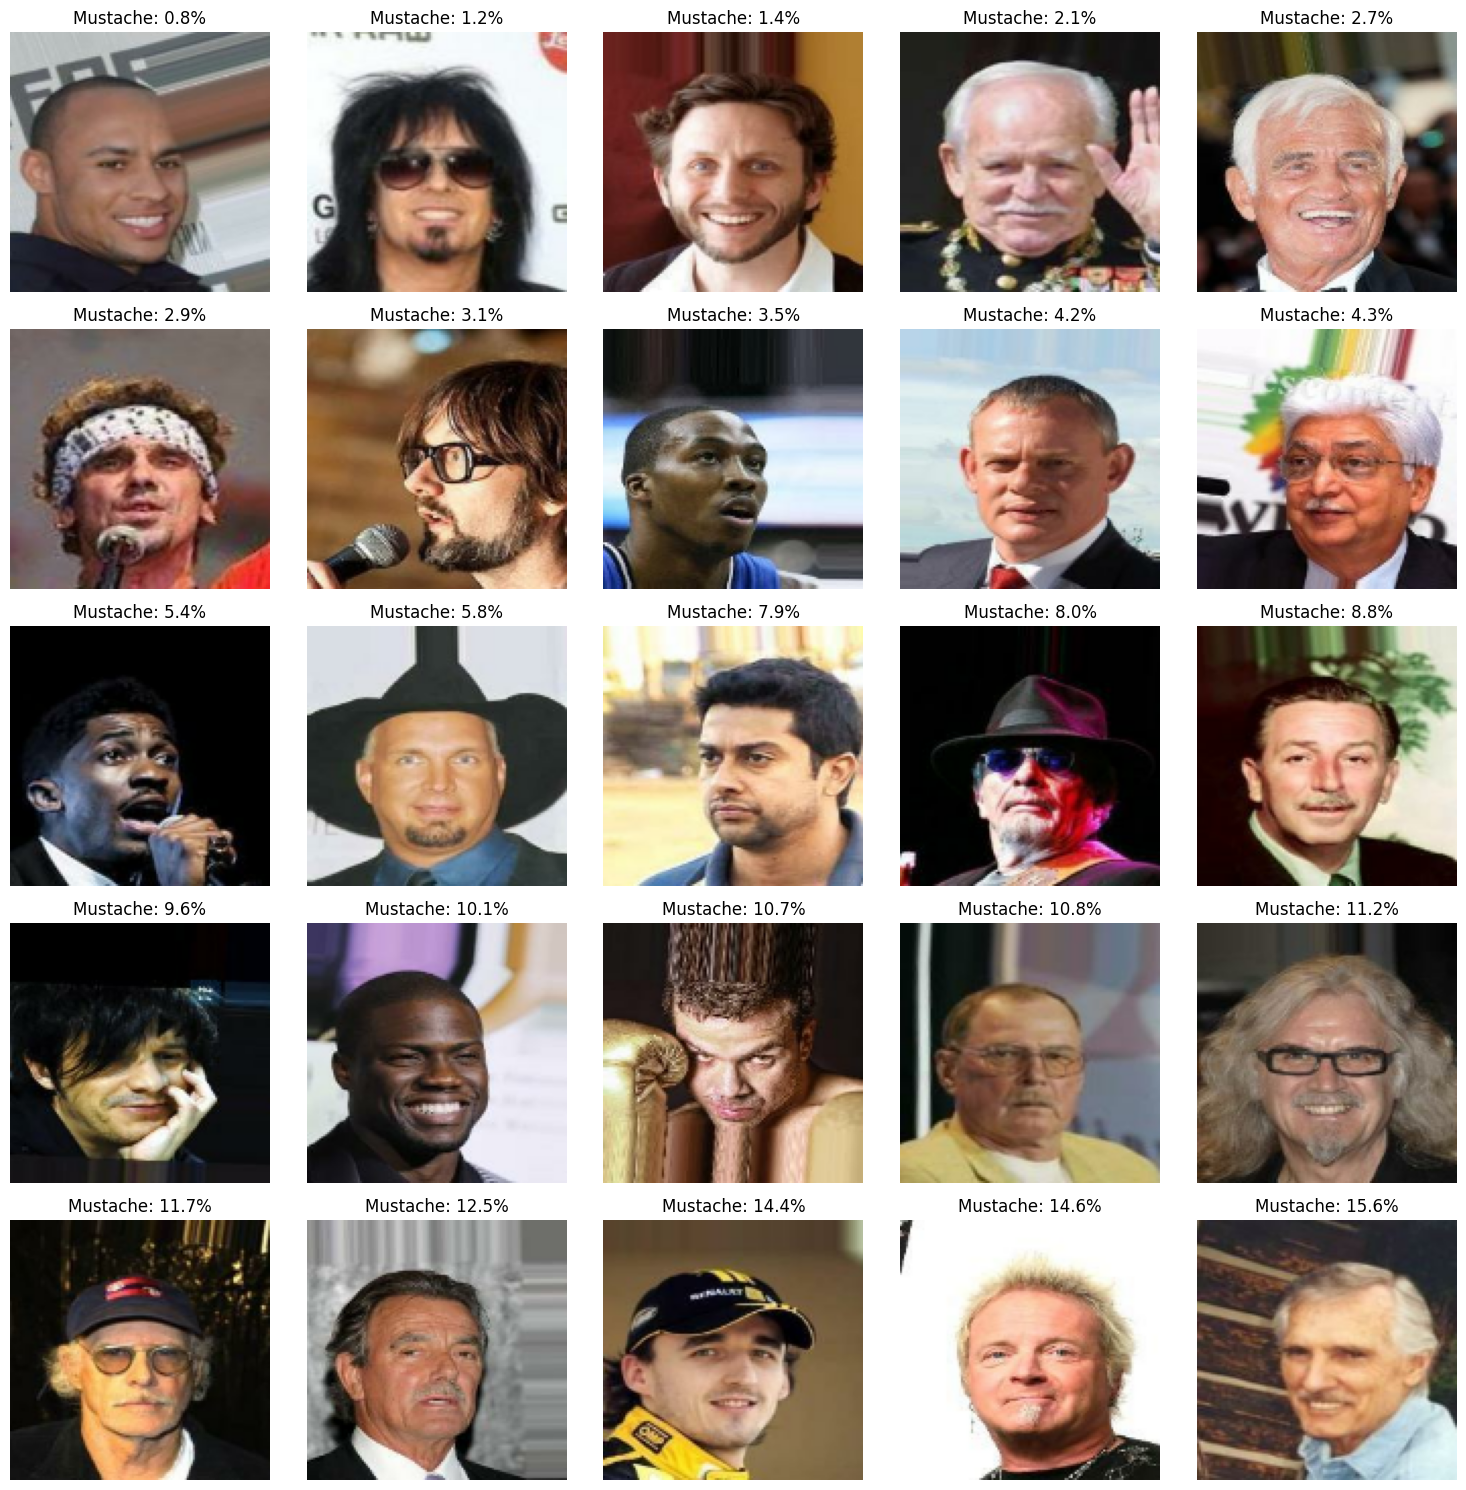

In [50]:
# True mustache men modellen tror clean
missed_mustache_idx = np.where(
    (true_arr == 1) & (pred_arr < 0.5)
)[0]

# sortera efter mest fel, alltså lägst mustasch-score
missed_sorted = missed_mustache_idx[np.argsort(pred_arr[missed_mustache_idx])]

plt.figure(figsize=(15, 15))

for i, idx in enumerate(missed_sorted[:25]):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images_arr[idx].astype("uint8"))
    plt.title(f"Mustache: {pred_arr[idx]*100:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

Modellen har svårt hitta mustascher på dessa bilder, helt rimligt det har jag också. Nu tränar vi den på bra vs dåliga mustascher.

In [51]:
img_size = (128, 128)

batch_size = 16

epic_train_ds = tf.keras.utils.image_dataset_from_directory(

    "data/epic_dataset",

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=img_size,

    batch_size=batch_size,

    label_mode="binary"

)

epic_val_ds = tf.keras.utils.image_dataset_from_directory(

    "data/epic_dataset",

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=img_size,

    batch_size=batch_size,

    label_mode="binary"

)

print(epic_train_ds.class_names)

Found 437 files belonging to 2 classes.
Using 350 files for training.
Found 437 files belonging to 2 classes.
Using 87 files for validation.
['epic', 'thin']


In [53]:


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

epic_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [56]:
epic_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

In [57]:
history_epic = epic_model.fit(
    epic_train_ds,
    validation_data=epic_val_ds,
    epochs=60,
    callbacks=[early_stop]
)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.5200 - loss: 0.7092 - val_accuracy: 0.5402 - val_loss: 0.6722
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.5543 - loss: 0.6797 - val_accuracy: 0.6667 - val_loss: 0.6200
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.7057 - loss: 0.5702 - val_accuracy: 0.8046 - val_loss: 0.4196
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.8543 - loss: 0.3855 - val_accuracy: 0.8736 - val_loss: 0.2878
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.8857 - loss: 0.2924 - val_accuracy: 0.9080 - val_loss: 0.1567
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8971 - loss: 0.2589 - val_accuracy: 0.9310 - val_loss: 0.1589
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9286 - loss: 0.2006 - val_accuracy: 0.9195 - val_loss: 0.1683
Epoch 8/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9143 - loss: 0.2149 - val_accuracy: 0.

Ser fint ut!

In [58]:
epic_model.evaluate(epic_val_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9425 - loss: 0.1182


[0.11818894743919373, 0.9425287246704102]

In [59]:


y_true = []

y_pred = []

for images, labels in epic_val_ds:

    predictions = epic_model.predict(

        images,

        verbose=0

    ).flatten()

    predicted_labels = (

        predictions > 0.5

    ).astype(int)

    y_true.extend(labels.numpy().astype(int))

    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[37  3]
 [ 2 45]]


2026-06-02 07:57:35.515444: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


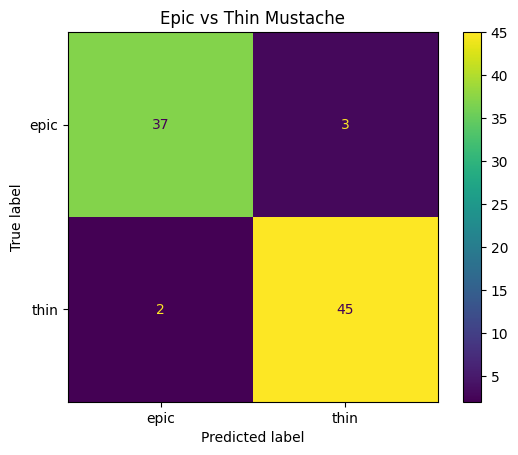

In [60]:


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=epic_train_ds.class_names
)

disp.plot(values_format="d")
plt.title("Epic vs Thin Mustache")
plt.show()

Spara modellerna

In [62]:

os.makedirs("models", exist_ok=True)

model.save("models/mustache_detector.keras")

epic_model.save("models/epic_detector.keras")

2026-06-02 09:02:17.711944: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


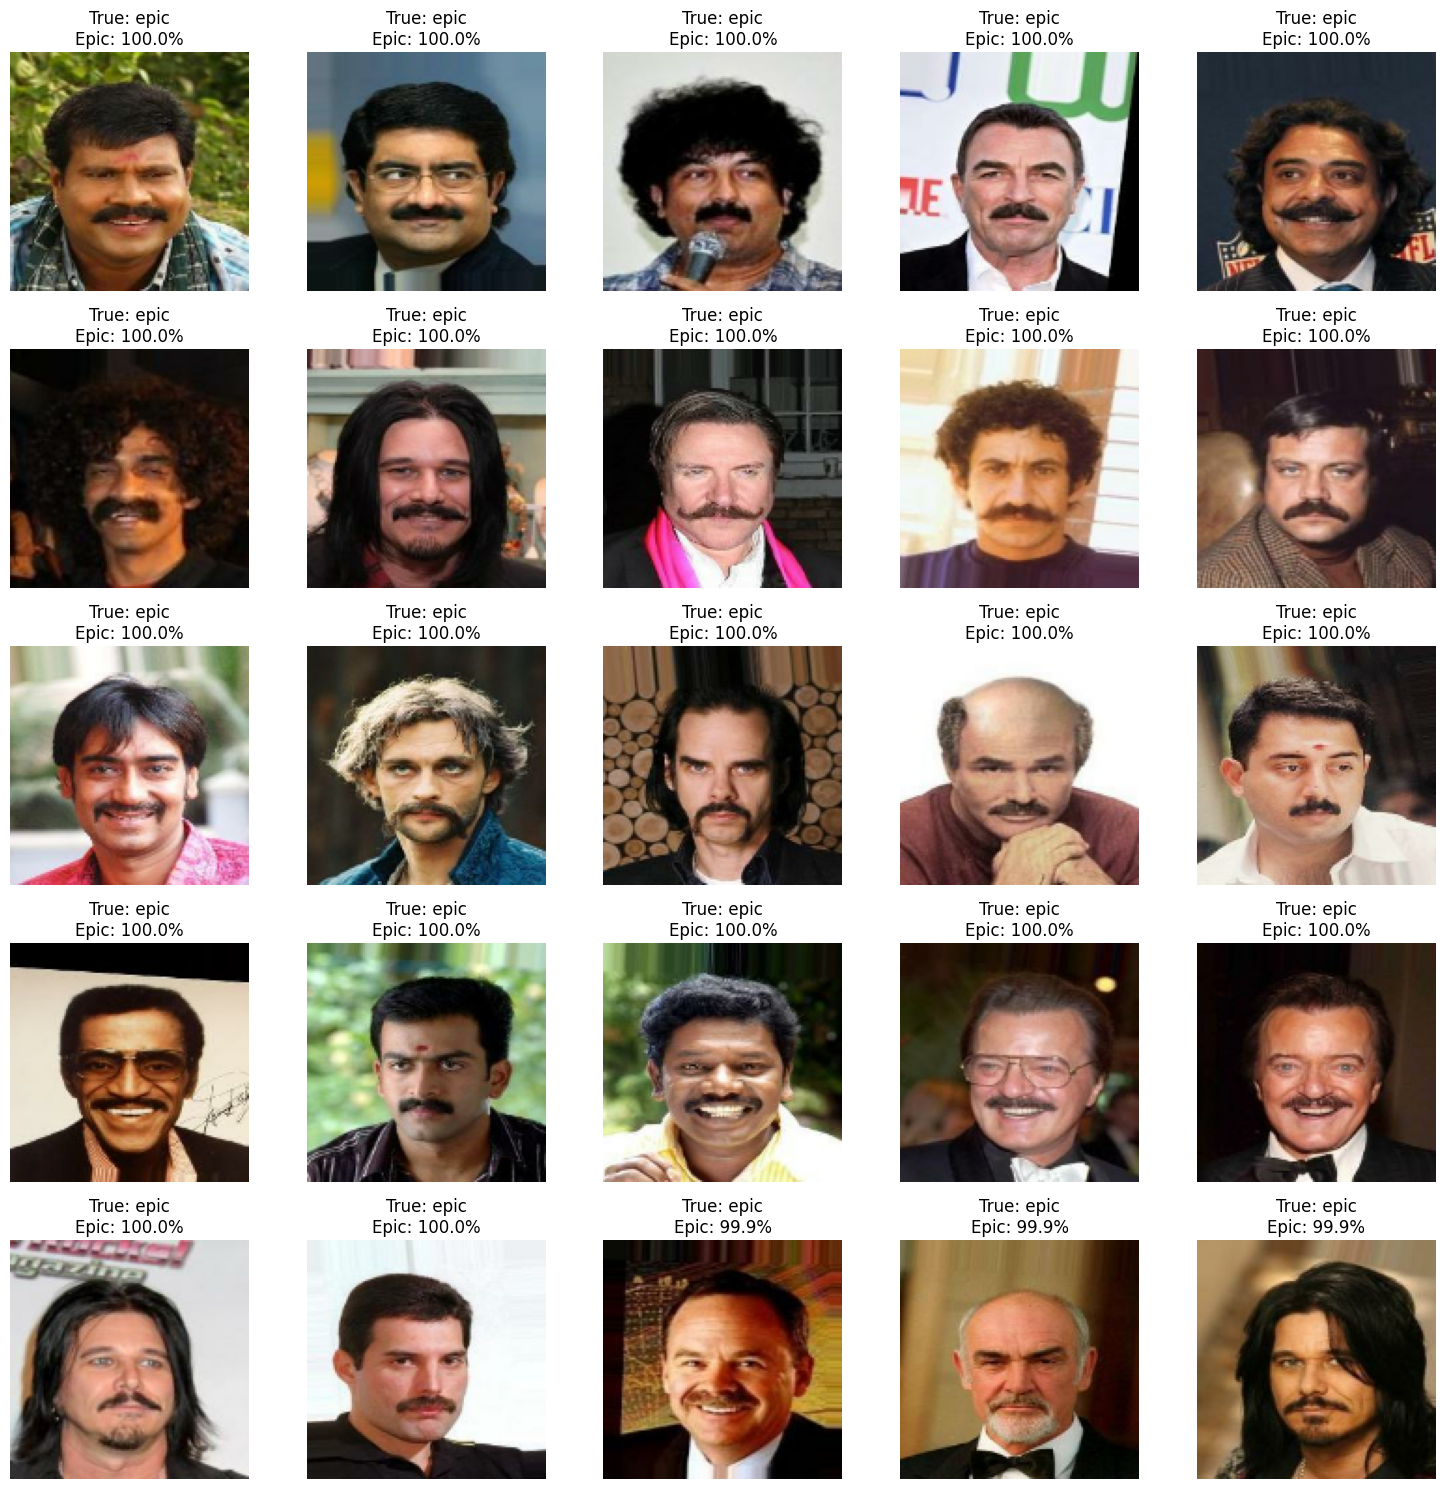

In [64]:
import numpy as np
import matplotlib.pyplot as plt

images_list = []
true_labels = []
pred_probs = []

for images, labels in epic_val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    images_list.append(images.numpy())
    true_labels.append(labels.numpy().flatten())
    pred_probs.append(preds)

images_arr = np.concatenate(images_list)
true_arr   = np.concatenate(true_labels)
pred_arr   = np.concatenate(pred_probs)

# epic_score = 1 - thin_prob, precis som i appen
epic_scores = 1 - pred_arr

# Top 25 som modellen är mest säker på är EPIC
top_idx = np.argsort(epic_scores)[-25:][::-1]

plt.figure(figsize=(15, 15))
for i, idx in enumerate(top_idx):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images_arr[idx].astype("uint8"))
    true_label = epic_val_ds.class_names[int(true_arr[idx])]
    plt.title(f"True: {true_label}\nEpic: {epic_scores[idx]*100:.1f}%")
    plt.axis("off")
plt.tight_layout()
plt.show()